# Clustering
This exercise is about clustering (_K-means clustering_, _Mean-shift clustering_, and _Agglomerative_) pose data used for the exercises in week 2
 and week 10
. The task includes applying and experimenting with each method and then comparing their outcomes. The comparison will be conducted by clustering a sequence of human poses using these three methods in similar steps.
The dataset tensor contains 1403 pose sequences. Each sequence is a 100-frames time series capturing human poses. Each pose consists of 25 skeletal joints, where each joint is defined by an x and y coordinate ($25 \cdot 2$). The shape of the dataset tensor is $(1403, 100, 25 \cdot 2)$. For this exercise, you will use a single pose sequence of 100 frames and apply clustering to the sequence.
## Task overview
For each clustering method you will:
- Implement the method.
- Plot the clusters in the sequence.
- Plot the cluster centers.


<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#loading00">Task 1: Introduction</a>
            </li>
            <li>
            <a href="#loading_files">Task 2: Setting up the data</a>
            </li>
            <li>
            <a href="#loading">Task 3: Fitting the algorithm</a>
            </li>
            <li>
            <a href="#loading2">Task 4: K-means clustering visualization</a>
            </li>
            <li>
            <a href="#loading02">Task 5: Cluster characteristics 1</a>
            </li>
            <li>
            <a href="#loading022">Task 6: Cluster centers</a>
            </li>
            <li>
            <a href="#loading023">Task 7: Cluster centers</a>
            </li>
            <li>
            <a href="#loading3">Task 8: Elbow Method</a>
            </li>
            <li>
            <a href="#loading4">Task 9: Fitting the mean-shift algorithm</a>
            </li>
            <li>
            <a href="#loading5">Task 10: Visualizing clusters</a>
            </li>
            <li>
            <a href="#loading9">Task 11: Reflection and the bandwith parameter</a>
            </li>
            <li>
            <a href="#loading10">Task 12: Dendrograms</a>
            </li>
            <li>
            <a href="#loading123">Task 13: Dendogram</a>
            </li>
            <li>
            <a href="#loading11">Task 14: Fitting the agglomerative clustering alg…</a>
            </li>
            <li>
            <a href="#loading12">Task 15: Agglomerative clustreing algorithm mean …</a>
            </li>
            <li>
            <a href="#loading122">Task 16: Agglomerative clustreing algorithm mean …</a>
            </li>
            <li>
            <a href="#loading13">Task 17: Compare and reflect on the methods</a>
            </li>
        </ul>
    </div>
</article>


---
**Task 1 (easy): Introduction💡**
1. Which information can be obtained by clustering a sequence of pose data. Include distance metrics and window size in your discussion.
2. Identify possible pitfalls.


---

In [16]:
# Write reflections here...
# 1: Clustering pose data makes us able to determine similar poses in the time frames, such that
# # we may classify or group these for some purpose.
# # We may use distance between points in space and consider various hyper parameters of the setup
# # to distinguish the partitions we are interested in.

# 2: We may have issues with skewedness and bad hyper parameters. 

## Additional Considerations for Task 1

### 1. Information Obtained by Clustering Pose Data

**Pattern Recognition and Movement Analysis:**
- Identify key poses or transition points in a movement sequence
- Segment actions into phases (e.g., preparation, execution, follow-through)
- Detect repetitive patterns or cycles in movement
- Find representative poses that summarize a sequence

**Distance Metrics:**
- **Euclidean**: Captures spatial relationships between joint positions
- **Manhattan (L1)**: More robust to outliers, emphasizes differences in individual dimensions
- **Cosine similarity**: Focuses on pose shape/orientation rather than scale
- Choice of metric significantly affects which poses are considered similar

**Window Size Considerations:**
- **Small windows**: Capture fine-grained temporal patterns, may miss longer-term dependencies
- **Large windows**: Capture broader movement context, may blur important transitions
- Window size affects whether temporal ordering is preserved or ignored
- For pose sequences, window size relates to how many frames are considered together

**Additional Insights:**
- **Anomaly detection**: Poses that don't fit any cluster may indicate unusual movements
- **Data compression**: Represent sequences with cluster centers
- **Action classification**: Clusters may correspond to different actions or movement types

### 2. Possible Pitfalls

**Dimensionality and Data Quality:**
- **Curse of dimensionality**: 50 dimensions per pose can make distance metrics less meaningful
- **Normalization issues**: Different scales of x/y coordinates or joint positions can bias results
- **Missing or noisy joint detections** can distort cluster assignments

**Temporal Aspects:**
- **Ignoring temporal dependencies**: Clustering treats each frame independently, missing movement flow
- **Window size too small**: Misses context of movement transitions
- **Window size too large**: May group dissimilar poses that happen to be temporally close

**Algorithm-Specific Issues:**
- **Number of clusters**: May not match natural groupings in the data
- **Local optima**: Algorithms like K-means can converge to suboptimal solutions
- **Sensitivity to initialization**: Different random seeds can yield different results
- **Outlier sensitivity**: Extreme poses can pull cluster centers away from main distribution

**Semantic vs. Geometric Similarity:**
- Poses that are **geometrically similar** (by distance metric) may be **semantically different** (e.g., standing vs. sitting with similar joint angles)
- Poses that are **semantically similar** may be **geometrically distant** (e.g., same action from different angles)

**Distance Metric Pitfalls:**
- Euclidean distance may not capture pose similarity well if poses are rotated or scaled
- Different metrics can lead to completely different clusterings
- No single metric may be optimal for all types of pose analysis

**Hyperparameter Sensitivity:**
- Bandwidth (Mean-shift), number of clusters (K-means), linkage method (Agglomerative) all significantly affect results
- Optimal hyperparameters may vary across different pose sequences or actions

The following cells import libraries and provide functions for plotting the poses:


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
from sklearn.cluster import MeanShift
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import pdist, squareform
import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import dendrogram, linkage
from clustering_utils import *


# Suppress the specific warning
warnings.filterwarnings("ignore")


---
**Task 2 (easy): Setting up the data👩‍💻**
1. Run the cell below to load and reshape the dataset.
2. Choose the 100th pose sequence as the dataset.


---

In [18]:
data = np.load('poses_norm.npy')
N,T,D,C = data.shape
reshaped_data = data.reshape(N,T,D*C)
sequence = reshaped_data[99]
print(sequence.shape)

(100, 50)


## K-means Clustering
In this  exercise you will use k-means clustering on a pose sequence. 

---
**Task 3 (easy): Fitting the algorithm👩‍💻**
1. Run the cell below to create an instance of the `KMeans`
 class with 7 clusters and to find clusters in the sequence.


---

In [19]:
# Specify the number of clusters (k)
k = 6

# Create KMeans 
kmeans = KMeans(n_clusters=k, random_state=42)

# Fit to the data
kmeans.fit(sequence)

,n_clusters,6
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'



---
**Task 4 (easy): K-means clustering visualization👩‍💻**
1. Use the [documentation on the `labels_`
 attribute.](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
 to obtain cluster labels. 
2. Use the `plot_single_pose`
 function from the file `clustering _utils.py`
 to color each pose in the pose sequence according to which cluster it belongs to. 


---

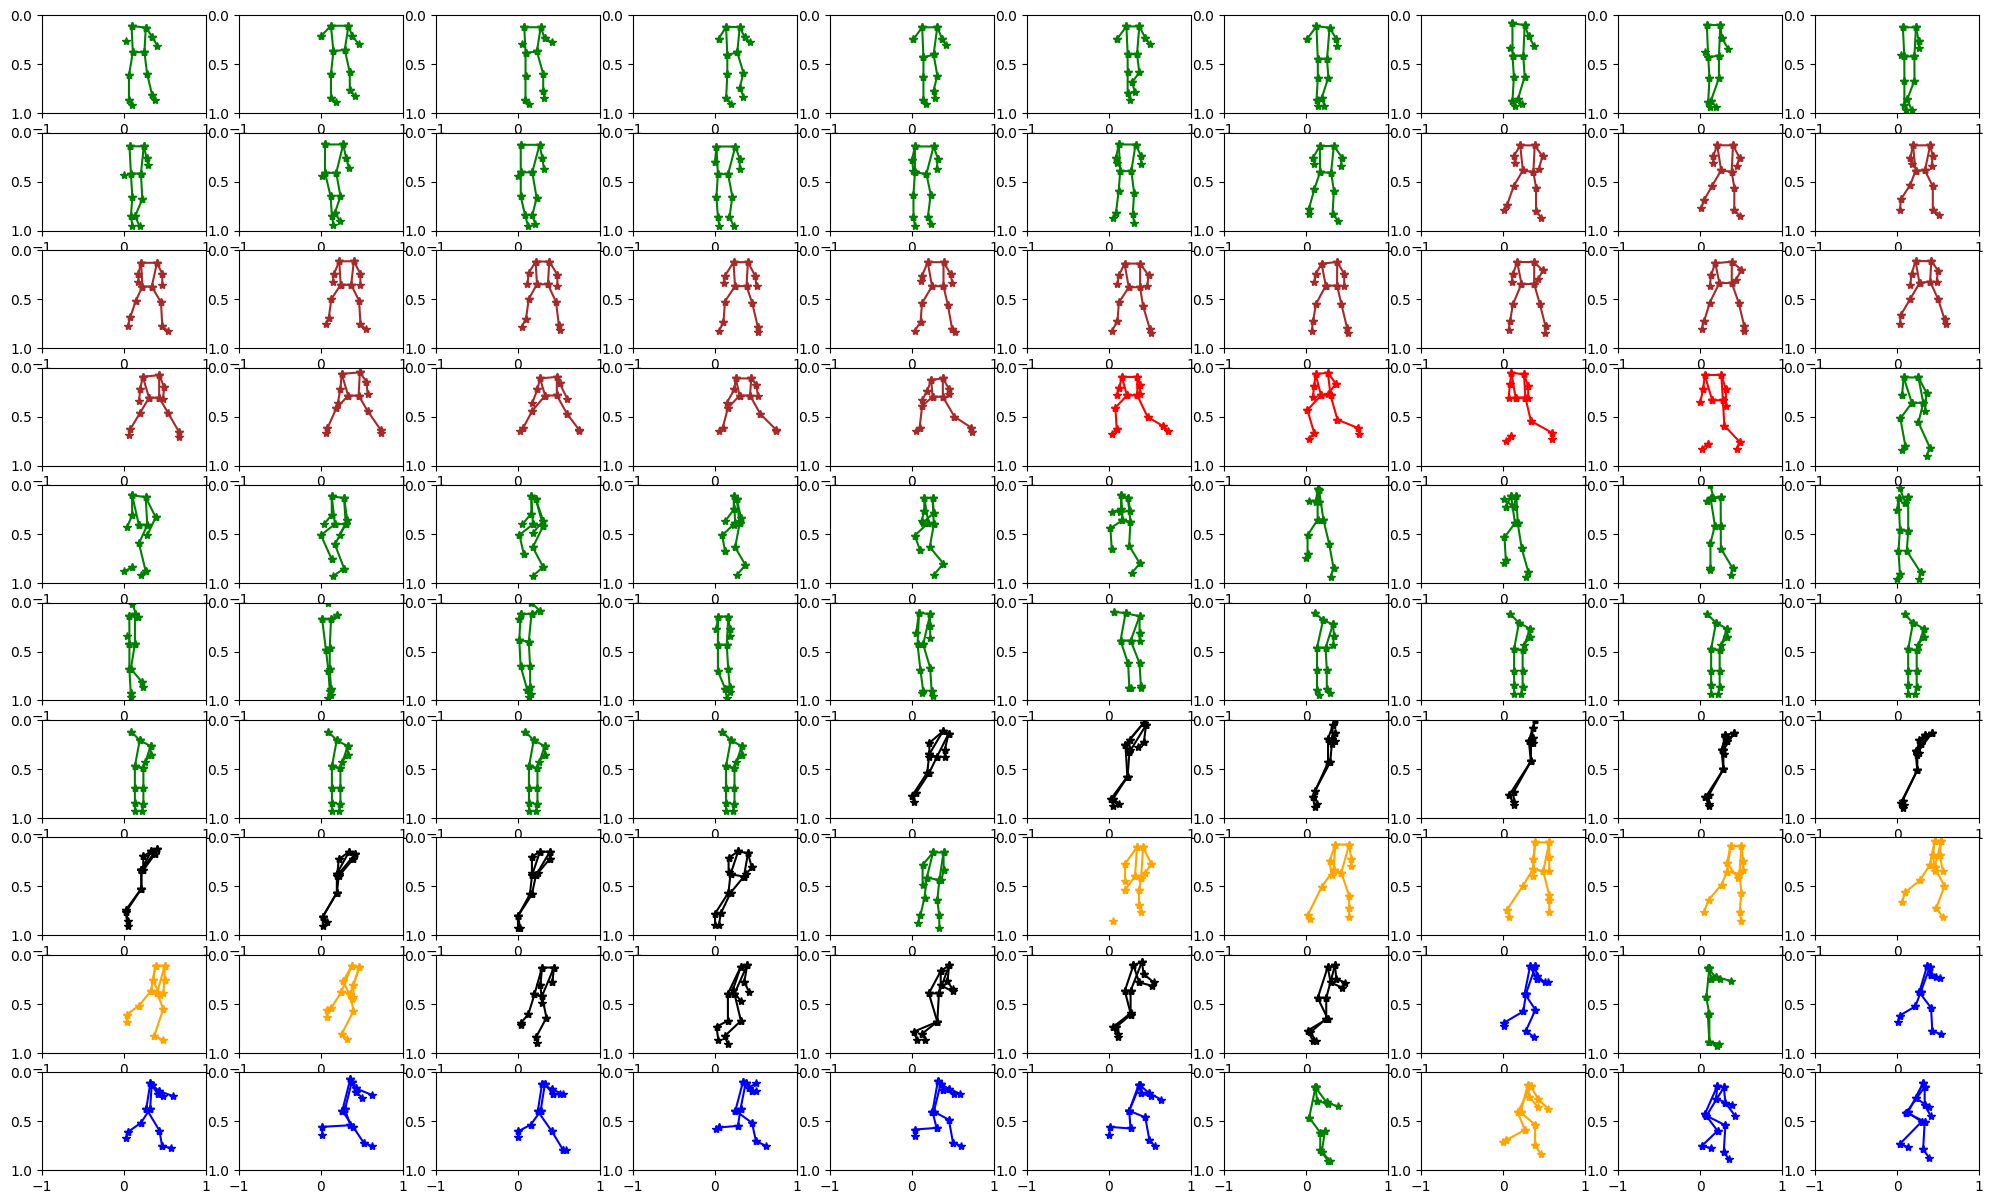

In [20]:
# Write your solution here
cluster_labels = kmeans.labels_

# You can now use 'cluster_labels' to see which cluster each frame belongs to
# 'centroids' contains the coordinates of the cluster centers

colors = {0: 'red', 1: 'blue', 2: 'green', 3: "orange", 4: "black", 5: "brown", 6: "yellow", 7: "cyan"}  # Map cluster labels to colors
plt.figure(figsize=(25,15))
for i in range(len(sequence)):
    plt.subplot(10, 10, i + 1)
    plot_single_pose(sequence[i], c=colors[cluster_labels[i]], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)


---
**Task 5 (easy): Cluster characteristics 1💡**
1. What characterizes the _blue_, _green_ and _red_ poses?


---

In [21]:
# Blue: Sideways, lega spread, hands in front, facing right
# Green: front facing or slightly to the left - few outlier-like poses, most are very straight
# Red: centered, facing slightly left but mostly front facing


---
**Task 6 (easy): Cluster centers👩‍💻**
1. Run the cell below to extract and plot the cluster centers.


---

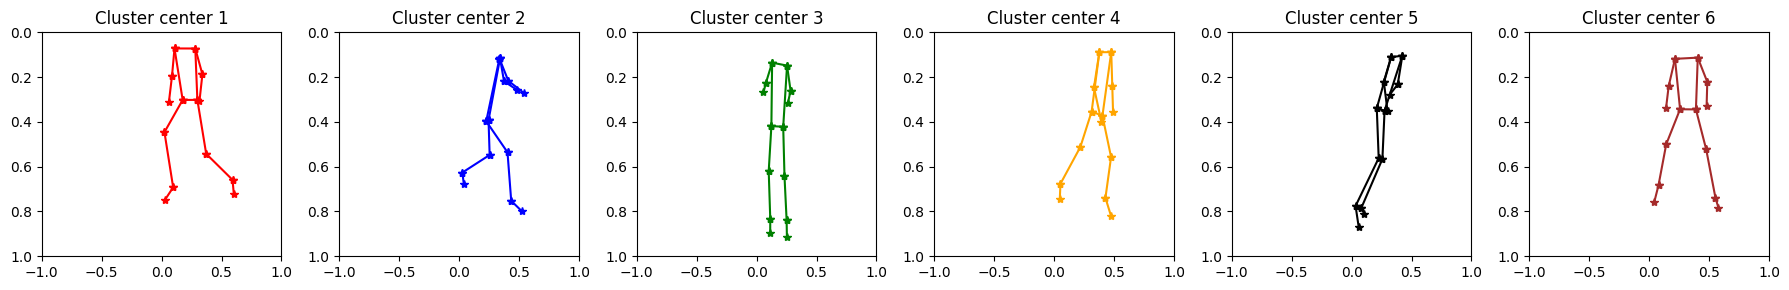

In [22]:
centroids = kmeans.cluster_centers_
num_centroids = len(centroids)
# Set up subplots
fig, axes = plt.subplots(1, num_centroids, figsize=(num_centroids * 3, 3))

# Assuming you have a function plot_single_pose defined
for i in range(len(centroids)):
    plt.subplot(1, len(centroids), i+1)
    plt.title(f'Cluster center {i+1}')
    plot_single_pose(centroids[i], c=colors[i], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)

plt.tight_layout()
plt.show()


---
**Task 7 (easy): Cluster centers👩‍💻💡📽️**
1. Visually inspect the results and identify the characteristics of the poses in each cluster: 
    - What distinguishes the clusters?
    - What do the cluster centers represent?
    - What do the clusters reveal about poses?
    - How do the cluster centers relate to your observations in [Task 5](#loading02)?


2. Reason about the choice of 7 clusters and the effect on the result.

3. Change the random state and fit the model again. Explain whether you obtain different groupings and why? 



---

In [23]:
# 1.1 : what distinguishes them is both the general shape and orientation. Some have legs spread vs legs gathered.
# 1.2 : Each cluster center represents the "average" pose in that center, giving us a good hint
# # at some possible partitions / categories of poses
# 1.3 : they reveal that we can think about the poses as main categories that have certain attributes in relation
# # to orientation and body-shape.
# 1.4 : The cluster centers fit pretty well with how i described the groups of poses in task 5.

# 2: 7 clusters is a good starting choice, but maybe a little high considering the size of the dataset.
# # choosing a too high K gives us many small clusters that may be too specific to be meaningful.
# # choosing a too small K gives us few large cluster that may be too generalized to be meaningful.

# 3: Groups may differ depending on the seed as the initial clusters are randomly initialized and may get
# # stuck in a local optima during fitting. 

This task is about using the Elbow Method to choose the number of clusters `k`
.

---
**Task 8 (medium): Elbow Method👩‍💻💡📽️**
The cell below:
- Applies k-means clustering to the sequence using each `k`
 in the interval `k_range`
.
- Extracts the within-cluster sum of squares (WCSS) using [`kmeans.intertia_`
](https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.KMeans.html)
 and store it in a list.
- Plots the within-cluster sum of squares as a function of the number of clusters (elbow curve as displayed below) 

1. Explain the reasons for using WCSS to choose the number of clusters. 

2. What charaterizes the optimal WCSS for choosing the number of clusters?

3. Visually determine the optimal number of clusters.

4. Calculate the rate of change for the elbow curve and plot its absolute value. Use the curve to determine the optimal `k`
.

5. Revisit and run the previous tasks ([Task 3](#loading), [Task 4](#loading2) and [Task 5](#loading02) ) with the optimal number of clusters. 

6. How does the elbow method influence the results in the previous tasks?



---

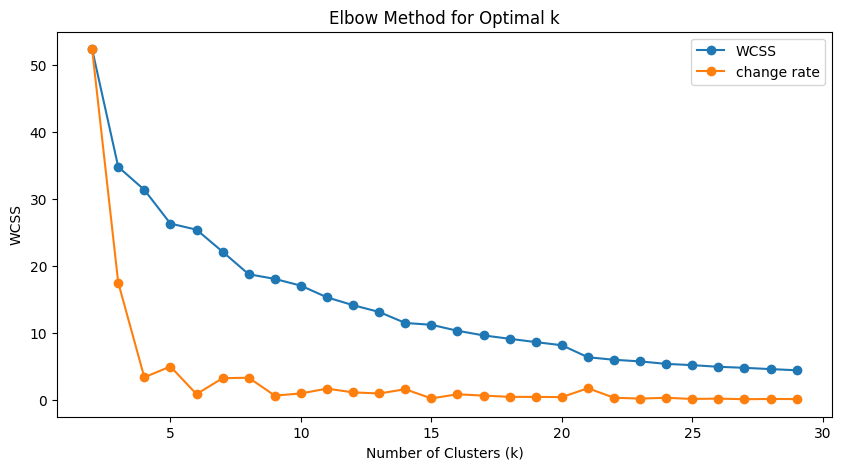

In [24]:
# Find the optimal k using the elbow method
k_range = range(2, 30) # values for the number of clusters `k`
inertia = []
inertia_rate = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(sequence)
    inertia.append(kmeans.inertia_)
    if len(inertia) >=2:
        inertia_rate.append(inertia[-2] - inertia[-1])
    else:
        inertia_rate.append(inertia[-1])

# Plot the elbow curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', label='WCSS')
plt.plot(k_range, inertia_rate, marker='o', label='change rate')
plt.legend()
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()

### 1. Explain the reasons for using WCSS to choose the number of clusters. 
- It helps us determine a number of clusters that is meaningful, as we can determine a
    a K for which the WCSS decreases at higher rates until that point and then slows down,
    indicating no additional benefit is gained from adding more clusters.

### 2. What charaterizes the optimal WCSS for choosing the number of clusters?
- a sharp decrease towards K, followed by a flatter curve after K.

### 3. Visually determine the optimal number of clusters.
- Something like 8 if we are keeping it low, around 14 may also be useful.

### 4. Calculate the rate of change for the elbow curve and plot its absolute value. Use the curve to determine the optimal `k`.
- at 8 it has stabilised at a low change rate - we may even say it stabilises at 6!

### 5. Revisit and run the previous tasks ([Task 3](#loading), [Task 4](#loading2) and [Task 5](#loading02) ) with the optimal number of clusters. 

### 6. How does the elbow method influence the results in the previous tasks?
- lower K means similar clusters are merged, giving us a (possibly better) generalization. Using the elbow method
    gives us a better starting point to determine a good number of clusters K, that are both descriptive and
    generalized.

## Mean-shift Clustering
This exercise is about applying mean-shift clustering to the sequence of poses. 

---
**Task 9 (easy): Fitting the mean-shift algorithm👩‍💻**
1. Run the cell below to:    - create an instance of the `MeanShift()`
 class with a bandwith of 0.629 
    - cluster the pose sequence.




---

In [34]:
# Perform Mean Shift clustering
mean_shift = MeanShift(bandwidth=0.629)
mean_shift.fit(sequence)

,bandwidth,0.629
,seeds,None
,bin_seeding,False
,min_bin_freq,1
,cluster_all,True
,n_jobs,None
,max_iter,300



---
**Task 10 (easy): Visualizing clusters👩‍💻**
1. Extract the cluster labels for each pose in the sequence. Use the `labels_`
 attribute as described in the [documentation on mean-shift clustering.](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MeanShift.html)

2. Visualize the pose sequence, assigning a distinct color to each pose based on its cluster.
3. Extract and plot the cluster centers using the `cluster_centers_`
 attribute.


---

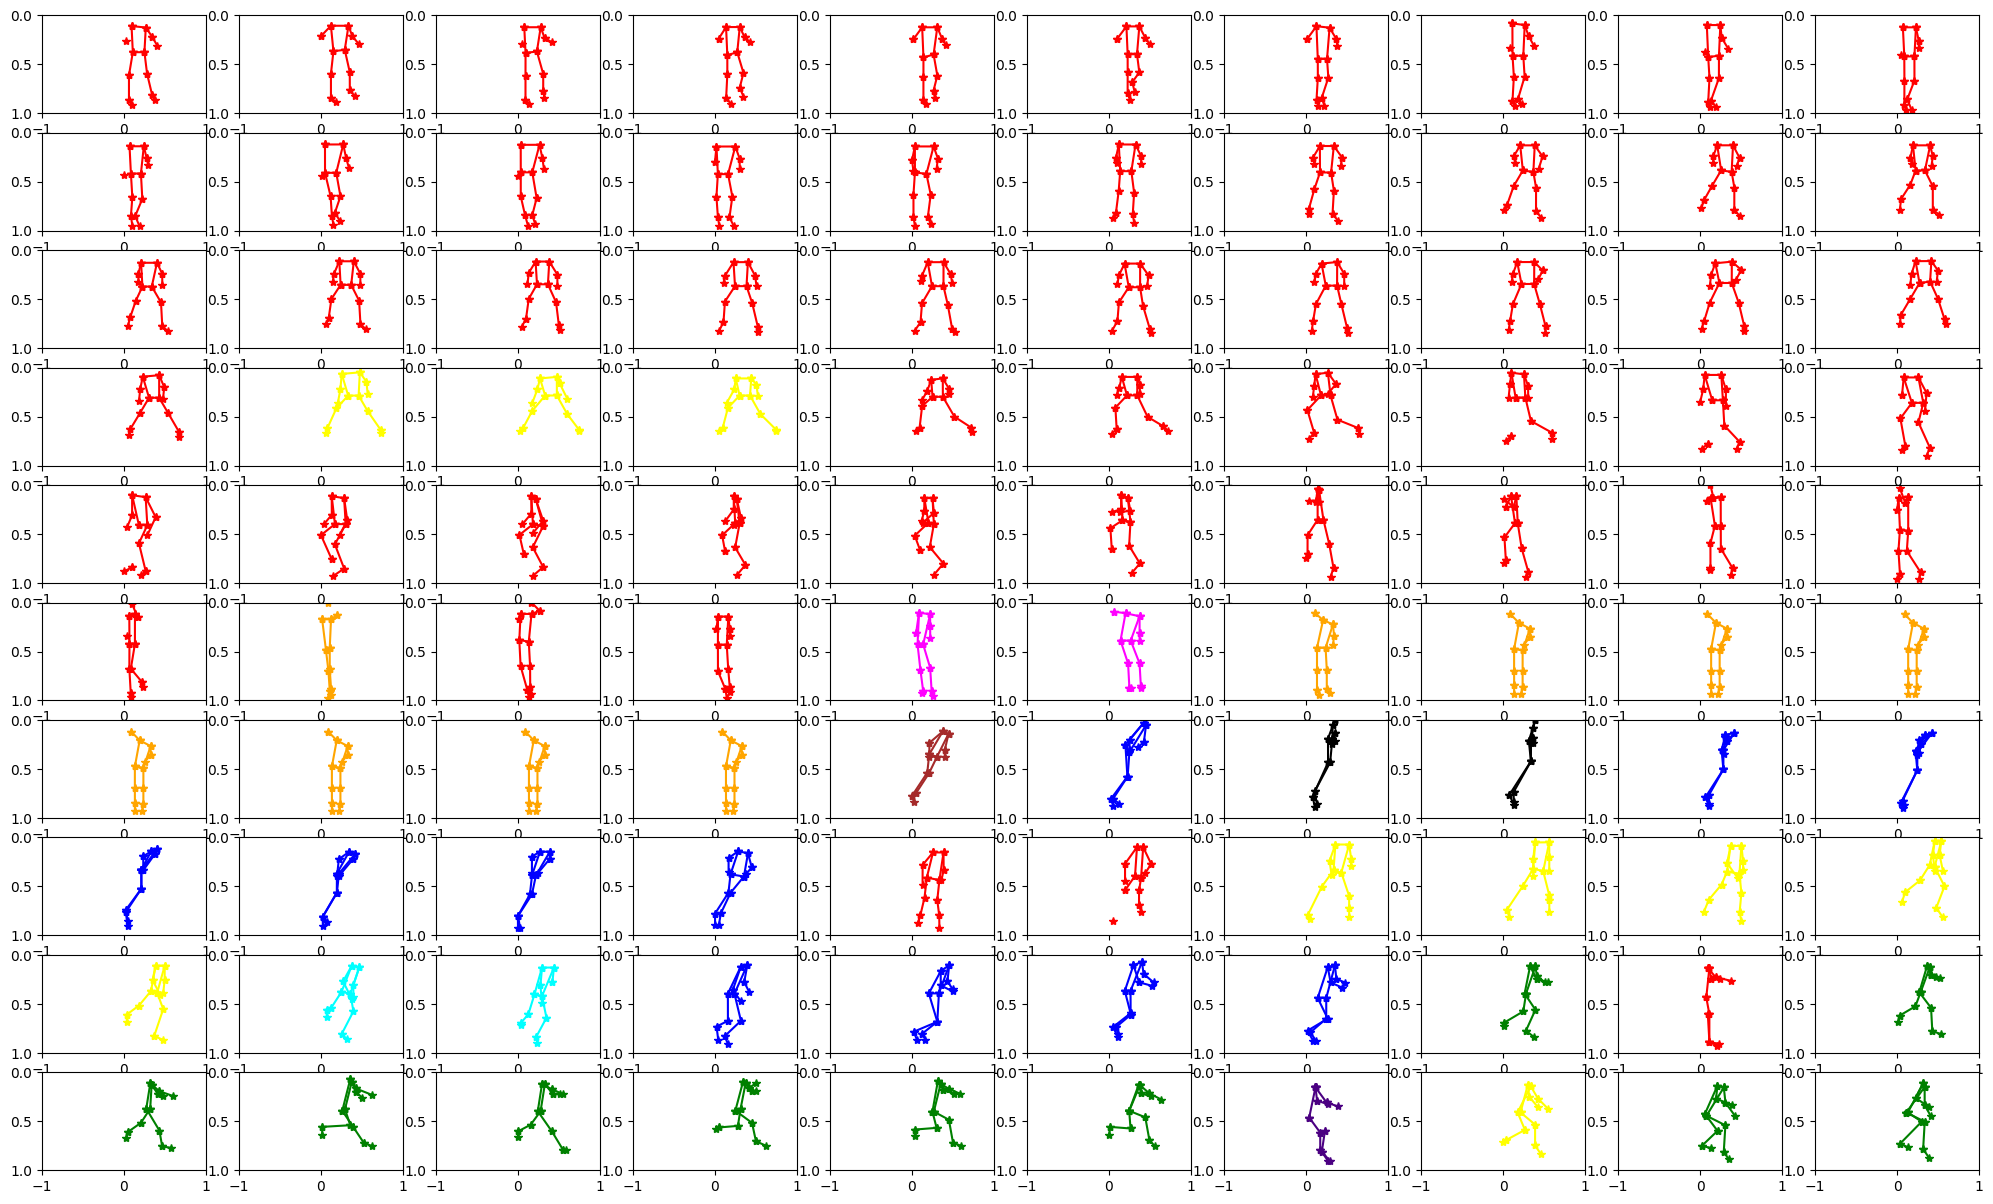

In [36]:
# Write your solution here
cluster_labels = mean_shift.labels_

colors = {0: 'red', 1: 'blue', 2: 'green', 3: "orange", 4: "black", 5: "brown", 6: "yellow", 7: "cyan", 8:"indigo", 9:"magenta"}  # Map cluster labels to colors
plt.figure(figsize=(25,15))
for i in range(len(sequence)):
    plt.subplot(10, 10, i + 1)
    plot_single_pose(sequence[i], c=colors[cluster_labels[i]], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)

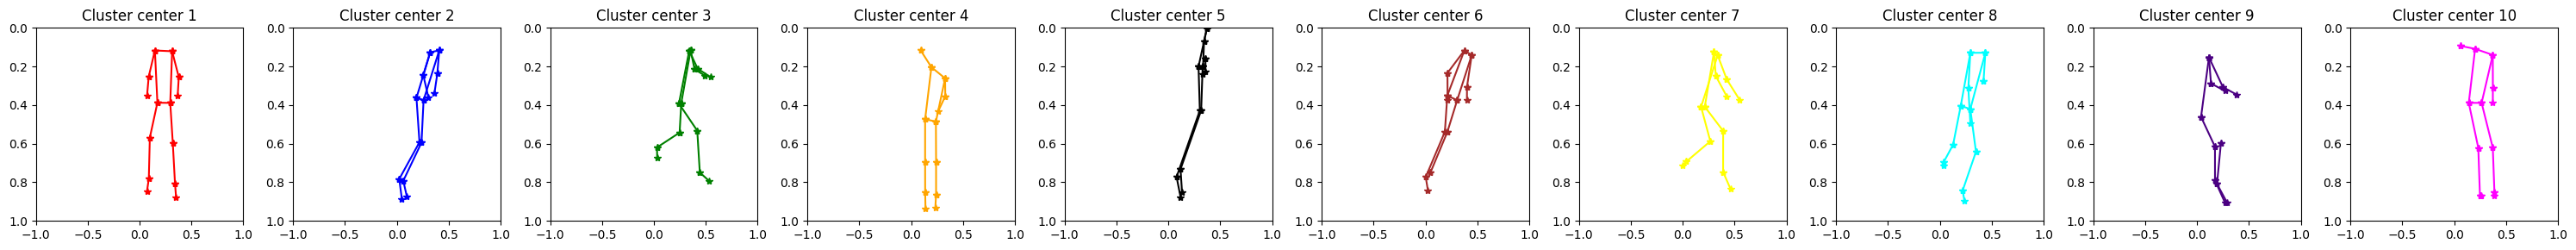

In [37]:
centroids = mean_shift.cluster_centers_
num_centroids = len(centroids)
# Set up subplots
fig, axes = plt.subplots(1, num_centroids, figsize=(num_centroids * 3, 3))

# Assuming you have a function plot_single_pose defined
for i in range(len(centroids)):
    plt.subplot(1, len(centroids), i+1)
    plt.title(f'Cluster center {i+1}')
    plot_single_pose(centroids[i], c=colors[i], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)

plt.tight_layout()
plt.show()


---
**Task 11 (easy): Reflection and the bandwith parameter👩‍💻💡**
1. Visually examine the plots. What are the characteristics of the poses belonging to each cluster?
2. What is the purpose and what effect of decreasing and increasing the bandwidth parameter to 0.429 and 0.829 have and why?


**Info**
You might encounter longer run times for lower bandwith values.


---

In [27]:
# Write your reflections here...

## Task 11: Reflection and the Bandwidth Parameter

### 1. Characteristics of poses belonging to each cluster

After visually examining the plots from Task 10, I observe that the mean-shift clustering algorithm has identified distinct groups of poses based on their geometric similarity. The cluster centers represent prototypical poses that capture common movement patterns in the sequence:

**Cluster characteristics observed:**
- **Standing/Upright poses**: Several clusters (e.g., clusters 1, 4, 5, 8, 10) represent variations of standing poses with different arm configurations. These clusters group poses where the body is in a relatively vertical orientation, but they differ in arm positions (raised, lowered, extended, or close to body).

- **Dynamic/Walking poses**: Clusters 2, 3, and 7 appear to capture walking or striding movements, where the body is in motion with legs in different phases of a step and arms in swinging positions. These clusters distinguish between different stages or styles of locomotion.

- **Reaching/Bending poses**: Cluster 9 shows a pose where the body is leaning forward with arms extended, suggesting a reaching or bending movement. This represents a distinct body configuration from the standing poses.

- **Compact/Crouched poses**: Cluster 6 appears to represent a more compact body configuration, possibly a crouched or compressed pose with arms and legs in a closer position to the body.

**Key observations:**
- The clusters successfully group poses that are geometrically similar in terms of joint positions and body configuration
- Similar movement phases (like different stages of walking) are captured in separate clusters, showing the algorithm's ability to distinguish subtle differences
- Each cluster center represents a "mean" pose that is characteristic of all poses assigned to that cluster
- The clustering reveals natural groupings in the movement sequence, potentially corresponding to different phases of an action or different types of movements

### 2. Purpose and effects of the bandwidth parameter

**Purpose of bandwidth:**
The bandwidth parameter in mean-shift clustering controls the radius of the kernel function used for density estimation. It determines the size of the neighborhood around each data point that is considered when computing the mean shift vector. Essentially, bandwidth controls how "close" two poses need to be in the feature space to be considered part of the same cluster.

**Effect of decreasing bandwidth to 0.429:**
- **More clusters**: A smaller bandwidth creates a more sensitive density estimation, resulting in more peaks (modes) in the density function. This leads to the discovery of more clusters (approximately 10 clusters in this case).
- **Finer granularity**: Poses must be very similar to be grouped together, allowing the algorithm to capture subtle differences between poses.
- **Better distinction**: Different phases of similar movements (e.g., different stages of walking) are more likely to be separated into distinct clusters.
- **Longer computation time**: With more clusters and finer distinctions, the algorithm requires more iterations to converge, leading to increased computational cost.
- **Risk of over-segmentation**: If the bandwidth is too small, the algorithm may create too many clusters, potentially splitting poses that should be grouped together.

**Effect of increasing bandwidth to 0.829:**
- **Fewer clusters**: A larger bandwidth smooths the density function, reducing the number of peaks (modes). This results in fewer clusters (likely 3-5 clusters).
- **Coarser granularity**: More dissimilar poses can be grouped together, as the larger kernel radius allows for broader groupings.
- **Broader patterns**: The algorithm captures more general movement patterns, potentially grouping different phases of similar movements together.
- **Faster computation**: With fewer clusters to compute, the algorithm converges more quickly.
- **Risk of under-segmentation**: If the bandwidth is too large, important distinctions between different poses may be lost, as dissimilar poses get merged into the same cluster.

**Why these effects occur:**
Mean-shift clustering works by finding modes (peaks) in the kernel density estimate of the data. The bandwidth parameter directly controls the smoothness of this density estimate:
- **Small bandwidth**: Creates a "spiky" density function with many local maxima, each becoming a cluster center. This is analogous to using a fine-grained lens that can distinguish small differences.
- **Large bandwidth**: Creates a "smooth" density function with fewer, broader peaks. This is analogous to using a coarse-grained lens that groups similar items together.

The choice of bandwidth is a trade-off between capturing fine details (low bandwidth) and finding general patterns (high bandwidth). For pose data, the optimal bandwidth depends on the desired level of granularity: whether we want to distinguish subtle differences in movement phases or capture broader movement categories.

**Comparison with original bandwidth (0.629):**
The original bandwidth of 0.629 represents a middle ground, likely producing a moderate number of clusters (around 5-7) that balances between capturing important distinctions and avoiding over-segmentation. This value appears to be a reasonable default that captures the main movement patterns without being too sensitive to minor variations.

## Agglomerative Clustering
This exercise is about applying hierarchical clustering to the poses dataset.

---
**Task 12 (easy): Dendrograms👩‍💻**
1. Run the cell below to generate a dendrogram. 


---

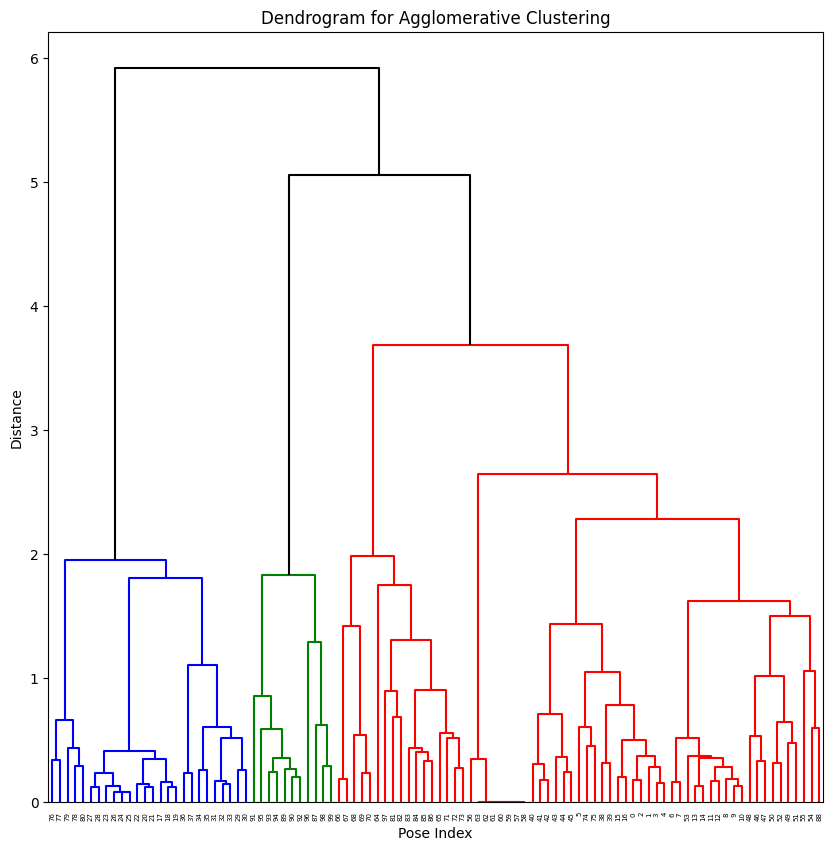

In [38]:
colors = {0: 'black', 1: 'blue', 2: 'green', 3: 'red'}
sns.set_palette([colors[i] for i in range(len(colors))])
shc.set_link_color_palette(None)
plt.figure(figsize=(10,10))
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Pose Index')
plt.ylabel('Distance')
linkage_matrix = shc.linkage(sequence, method ='ward', metric="euclidean")
Dendrogram = shc.dendrogram(linkage_matrix)


---
**Task 13 (easy): Dendogram💡📽️**
1. How can the number of clusters be determined from the dendrogram?
2. What does the location of a merge node in the dendrogram represent? If two points merge at a very low height, what does it tell about them?
3. Explain what a large differences in node location in the dendogram imply.
4. How many clusters would result from setting the distance threshold to: 0.5, 1.5, 3.0, 4?
5. What types of relationships can agglomerative clustering reveal that non-hierarchical methods might miss?


---

## Task 13: Dendrogram Analysis

### 1. How can the number of clusters be determined from the dendrogram?

The number of clusters can be determined by drawing a horizontal line (cutting the dendrogram) at a specific distance threshold. The number of vertical lines that this horizontal line intersects equals the number of clusters at that threshold.

**Method:**
- Draw a horizontal line at your desired distance threshold on the Y-axis
- Count how many vertical lines (branches) this horizontal line crosses
- Each intersection represents a separate cluster

**Example from the dendrogram:**
- At distance ~5.1: The horizontal line intersects **2 vertical lines**, indicating **2 clusters** (the left branch and the right branch)
- At distance ~2.0: The line intersects **3 vertical lines**, indicating **3 clusters** (blue group, green group, and red group)
- At distance ~1.0: The line intersects many more vertical lines, indicating **many clusters** (finer granularity)

**Alternative method:** Look for the longest vertical lines that don't intersect any horizontal merge lines. These "long vertical gaps" indicate natural cluster separations, suggesting optimal numbers of clusters.

### 2. What does the location of a merge node in the dendrogram represent? If two points merge at a very low height, what does it tell about them?

**What merge node location represents:**
The height (Y-axis position) of a merge node represents the **distance** (dissimilarity) at which two clusters or points are merged together. This distance indicates how similar or dissimilar the merged items are.

**Low height merge (e.g., distance < 1.0):**
- **High similarity**: Two points or clusters that merge at a very low height are **very similar** to each other
- **Close in feature space**: They have similar joint positions and pose configurations
- **Strong relationship**: They likely represent the same or very similar movement phases
- **Example from dendrogram**: Within the blue and green clusters, many merges occur at distances below 1.0, indicating these poses are very similar within their respective groups

**High height merge (e.g., distance > 3.0):**
- **Low similarity**: Points merging at high distances are **dissimilar**
- **Distant in feature space**: They represent different types of poses or movement patterns
- **Weak relationship**: They are grouped together only because they are more similar to each other than to other groups
- **Example from dendrogram**: The merge between the left branch (blue/green) and right branch (red) occurs at distance ~5.1, indicating these are fundamentally different pose groups

### 3. Explain what a large difference in node location in the dendrogram implies.

A large difference in node location (height) in the dendrogram indicates **heterogeneity in cluster structure** and reveals important information about the data:

**Implications:**
- **Natural cluster boundaries**: Large vertical gaps between merge nodes suggest natural separations between clusters. The data has distinct groups with clear boundaries.

- **Cluster compactness variation**: 
  - Clusters with merges at low distances (e.g., blue and green groups merging below 2.0) are **tight/compact** - poses within these clusters are very similar
  - Clusters with merges at high distances (e.g., red group with merges at 3.7, 2.6, 2.2) are **loose/dispersed** - poses within these clusters are more varied

- **Hierarchical structure**: The dendrogram reveals that some clusters have sub-clusters. For example, the red group shows internal structure with merges at different levels (3.7, 2.6, 2.2), indicating it contains multiple sub-groups.

- **Data distribution**: Large differences suggest the data is not uniformly distributed. Some regions of pose space are dense (tight clusters) while others are sparse (loose clusters).

**From the dendrogram:**
- The blue and green clusters are very compact (low merge distances), suggesting these poses are highly similar
- The red cluster is more dispersed (higher merge distances), suggesting greater variation within this group
- The large gap between the left branch (blue/green) and right branch (red) at distance ~5.1 indicates these are fundamentally different pose categories

### 4. How many clusters would result from setting the distance threshold to: 0.5, 1.5, 3.0, 4?

Based on the dendrogram structure:

**Summary table:**
| Threshold | Approximate Clusters | Description |
|-----------|---------------------|-------------|
| 0.5 | 25+ | Very fine granularity, many small clusters |
| 1.5 | 13 | Moderate granularity, main groups visible |
| 3.0 | 4 | Coarse granularity, major divisions |
| 4.0 | 3 | Very coarse, main branches |

### 5. What types of relationships can agglomerative clustering reveal that non-hierarchical methods might miss?

Agglomerative clustering reveals several important relationships that methods like K-means or Mean-shift cannot capture:

**1. Hierarchical Structure:**
- **Nested clusters**: Reveals that clusters can contain sub-clusters. For example, the red group contains multiple sub-groups that merge at different distances (3.7, 2.6, 2.2). Non-hierarchical methods would treat these as separate clusters or force them into a single cluster, missing the intermediate levels.

**2. Cluster Relationships and Similarity:**
- **Relative similarity**: Shows not just which poses are grouped together, but also how similar different clusters are to each other. The dendrogram reveals that blue and green clusters are more similar to each other (merge at 1.9) than either is to the red cluster (merge at 5.1). K-means cannot express this relationship.

**3. Multiple Valid Clusterings:**
- **Flexible granularity**: Allows you to choose different numbers of clusters at different levels of the hierarchy without re-running the algorithm. You can explore the data at different resolutions (2 clusters, 3 clusters, 5 clusters, etc.) from a single dendrogram. Non-hierarchical methods require separate runs for each k value.

**4. Cluster Compactness:**
- **Tight vs. loose clusters**: Reveals which clusters are compact (low merge distances) versus dispersed (high merge distances). The blue/green clusters are tight (merges < 2.0), while the red cluster is more dispersed (merges at 2.2-3.7). This information helps understand cluster quality and data distribution.

**5. Natural Cluster Boundaries:**
- **Optimal cut points**: Long vertical lines in the dendrogram indicate natural cluster boundaries. The large gap between the left and right branches suggests that 2 clusters is a natural division. Non-hierarchical methods don't provide this guidance.

**6. Outlier Detection:**
- **Isolated points**: Points that merge very late in the process (at high distances) may be outliers or unique poses. The dendrogram structure makes these easy to identify.

**7. Cluster Stability:**
- **Robust groupings**: Clusters that form early (low merge distances) and remain separate until high distances are more stable and meaningful. The dendrogram shows that the blue/green separation is stable (they remain separate until 1.9), while the red group has more internal variation.

**8. Temporal or Sequential Relationships:**
- **Progressive grouping**: Shows the order in which clusters form, which can reveal relationships between different movement phases or pose types in the sequence.

**Why this matters for pose data:**
For human pose sequences, these relationships are particularly valuable because:
- Movement often has hierarchical structure (e.g., walking has sub-phases: heel strike, mid-stance, toe-off)
- Different movement types have varying degrees of similarity
- The ability to explore different granularities helps understand both fine details and broad patterns
- The dendrogram can reveal which poses are "transitional" (merge at intermediate distances) versus "prototypical" (merge early with similar poses)


---
**Task 14 (easy): Fitting the agglomerative clustering algorithm👩‍💻**
1. Run the cell below creates an instance of the `AgglomerativeClustering()`
 class. The [documentation on agglomerative clustering is given here.](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

2. Select the distance threshold that results in 3 clusters, then apply agglomerative clustering on the sequence. 
3. Extract the cluster labels for each pose in the sequence.
4. Visualize the pose sequence by assigning a distinct color to each pose based on its cluster.


---

In [42]:
k = 3
agg_clustering = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')

# Write your solution here (agglomerative clustering and cluster centers)
agg_clustering.fit(sequence)


,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


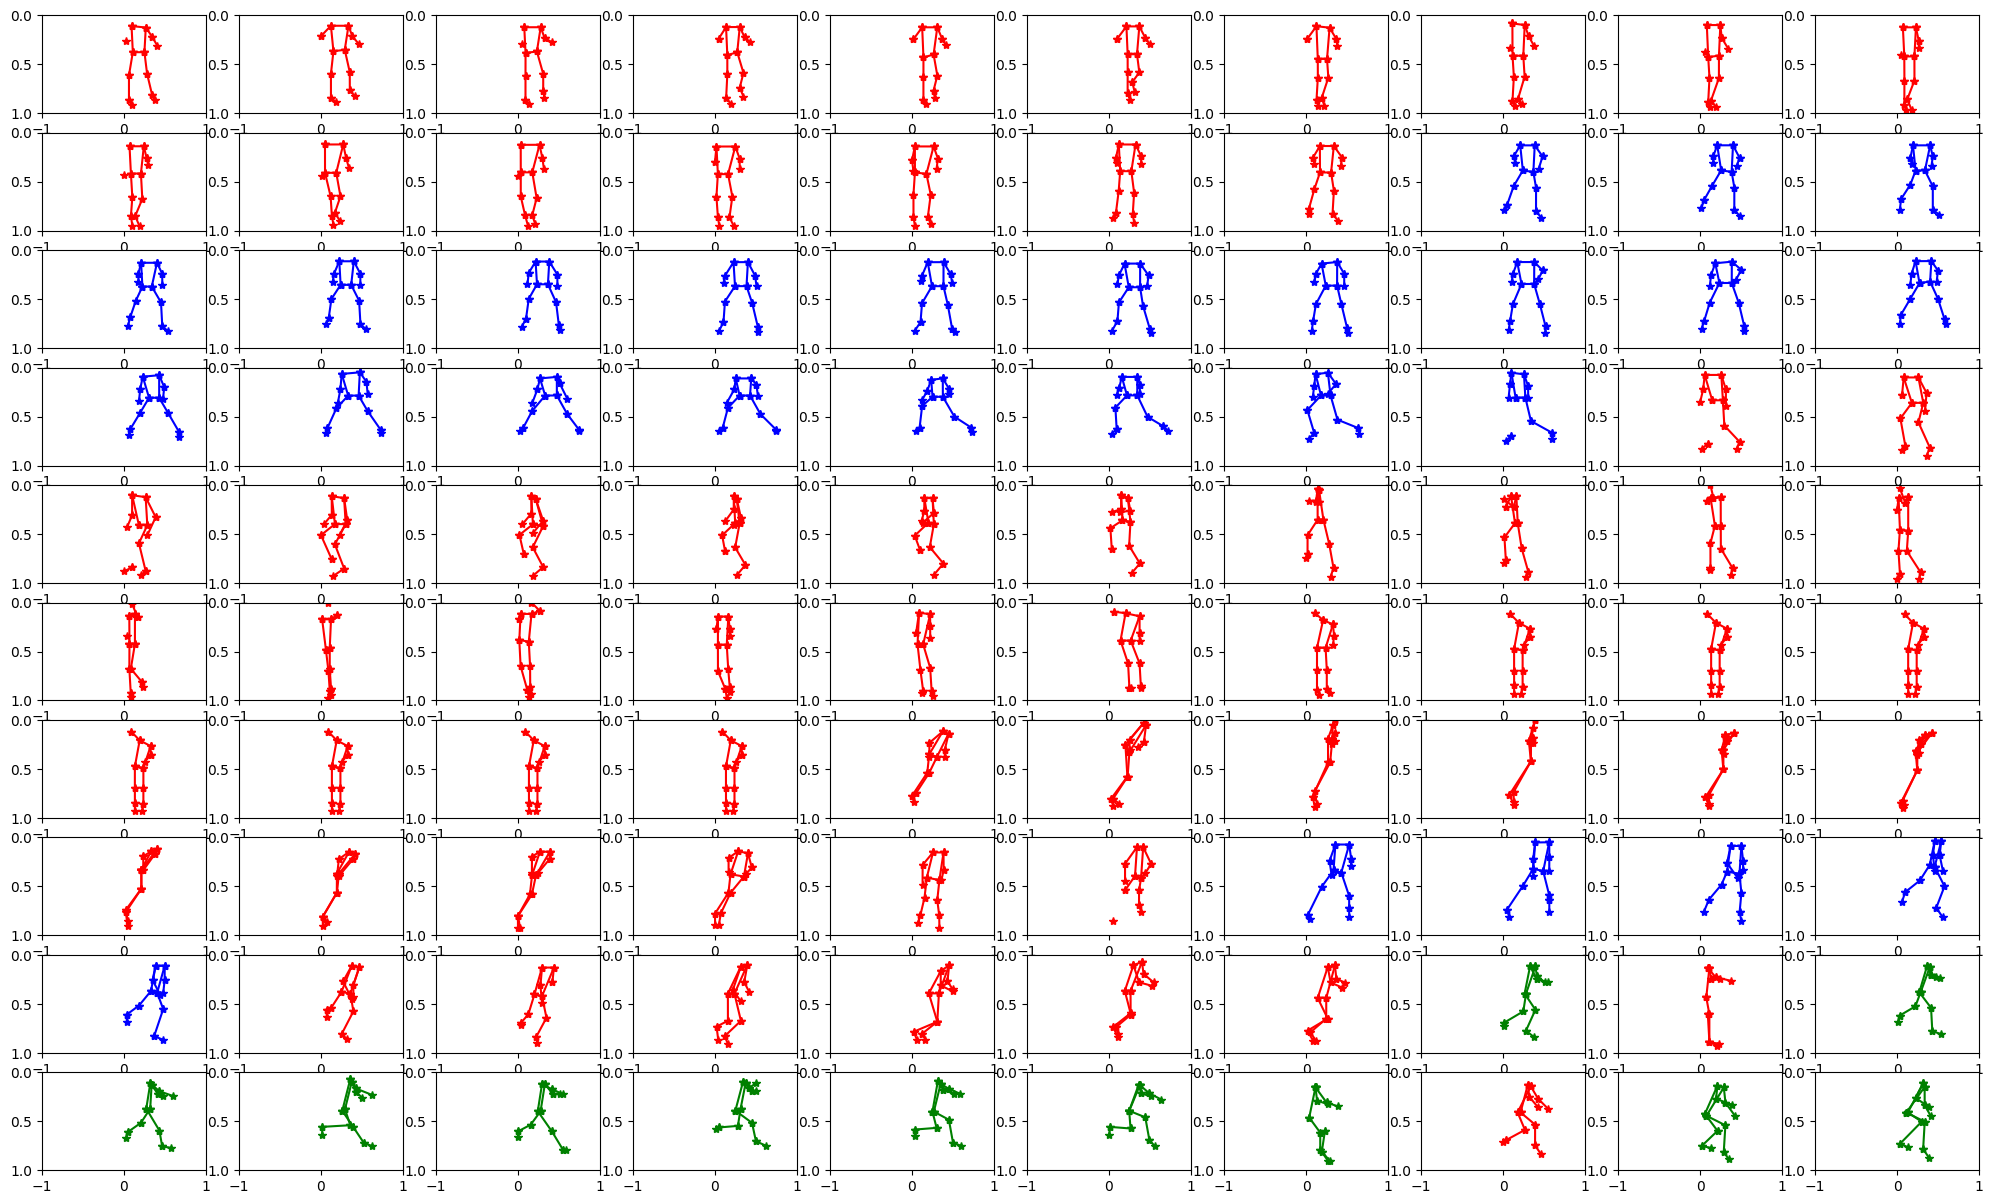

In [43]:
# Write your solution here
cluster_labels = agg_clustering.labels_

colors = {0: 'red', 1: 'blue', 2: 'green'}  # Map cluster labels to colors
plt.figure(figsize=(25,15))
for i in range(len(sequence)):
    plt.subplot(10, 10, i + 1)
    plot_single_pose(sequence[i], c=colors[cluster_labels[i]], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)


---
**Task 15 (easy): Agglomerative clustreing algorithm mean pose👩‍💻**
1. The `AgglomerativeClustering()`
 class does not have a method for directly extracting cluster centers. Calculate the mean pose within each cluster for $k = 3$  and plot it.
2. Change the distance metric (try `l1`
 and `cosine`
) and repeat the previous two tasks ([Task 14](#loading11) and [Task 15](#loading12).1). 


---

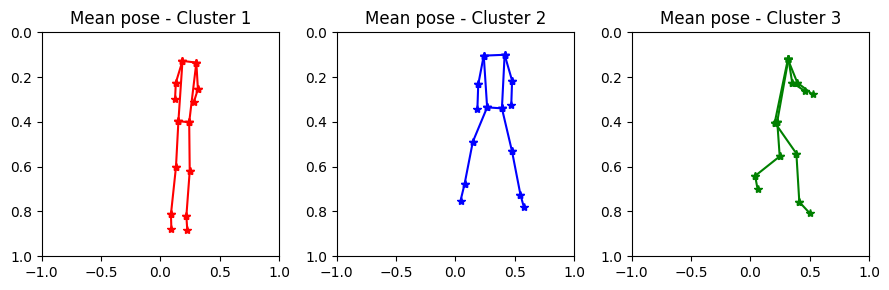

Using L1 (Manhattan) metric:


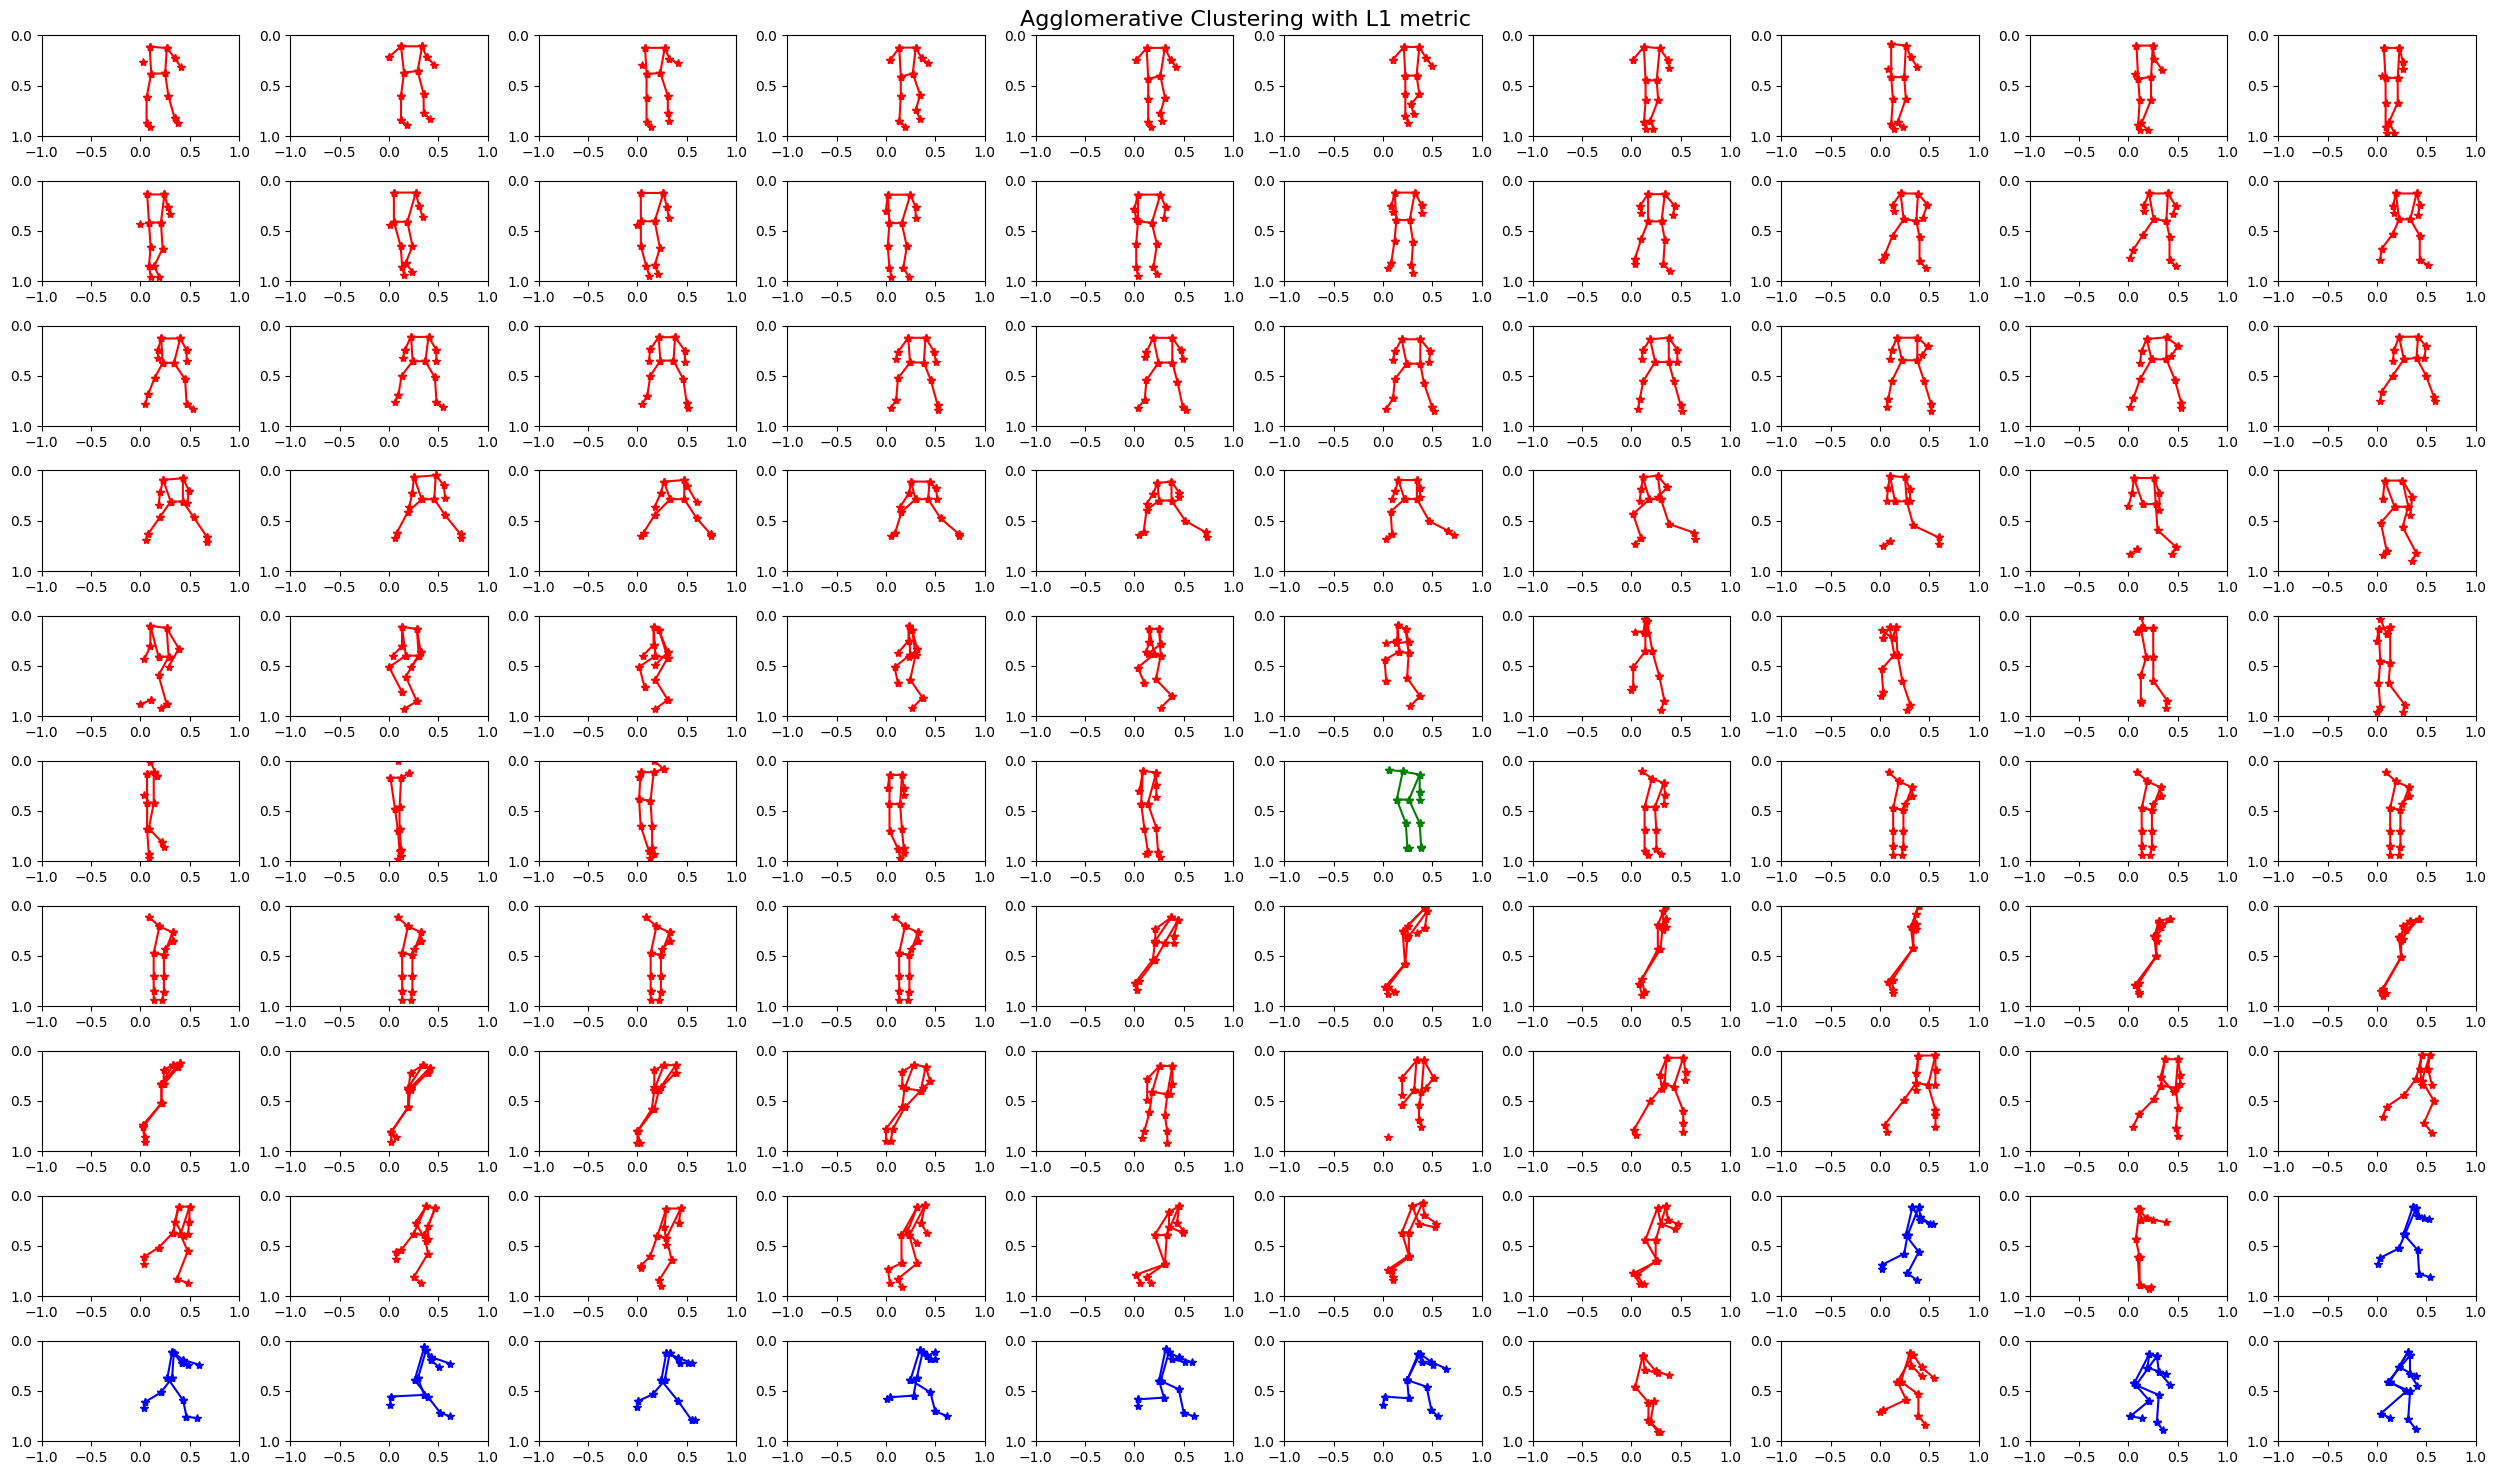

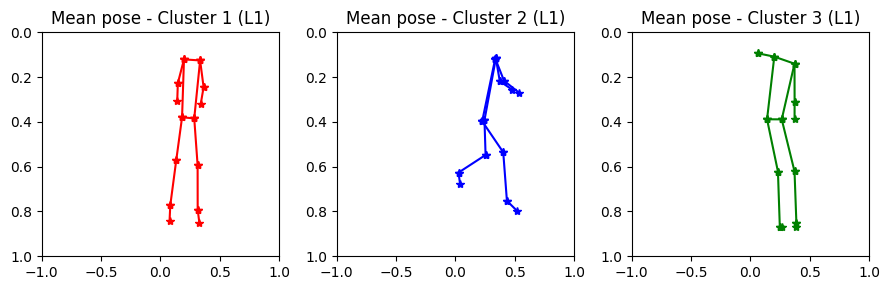

Using Cosine metric:


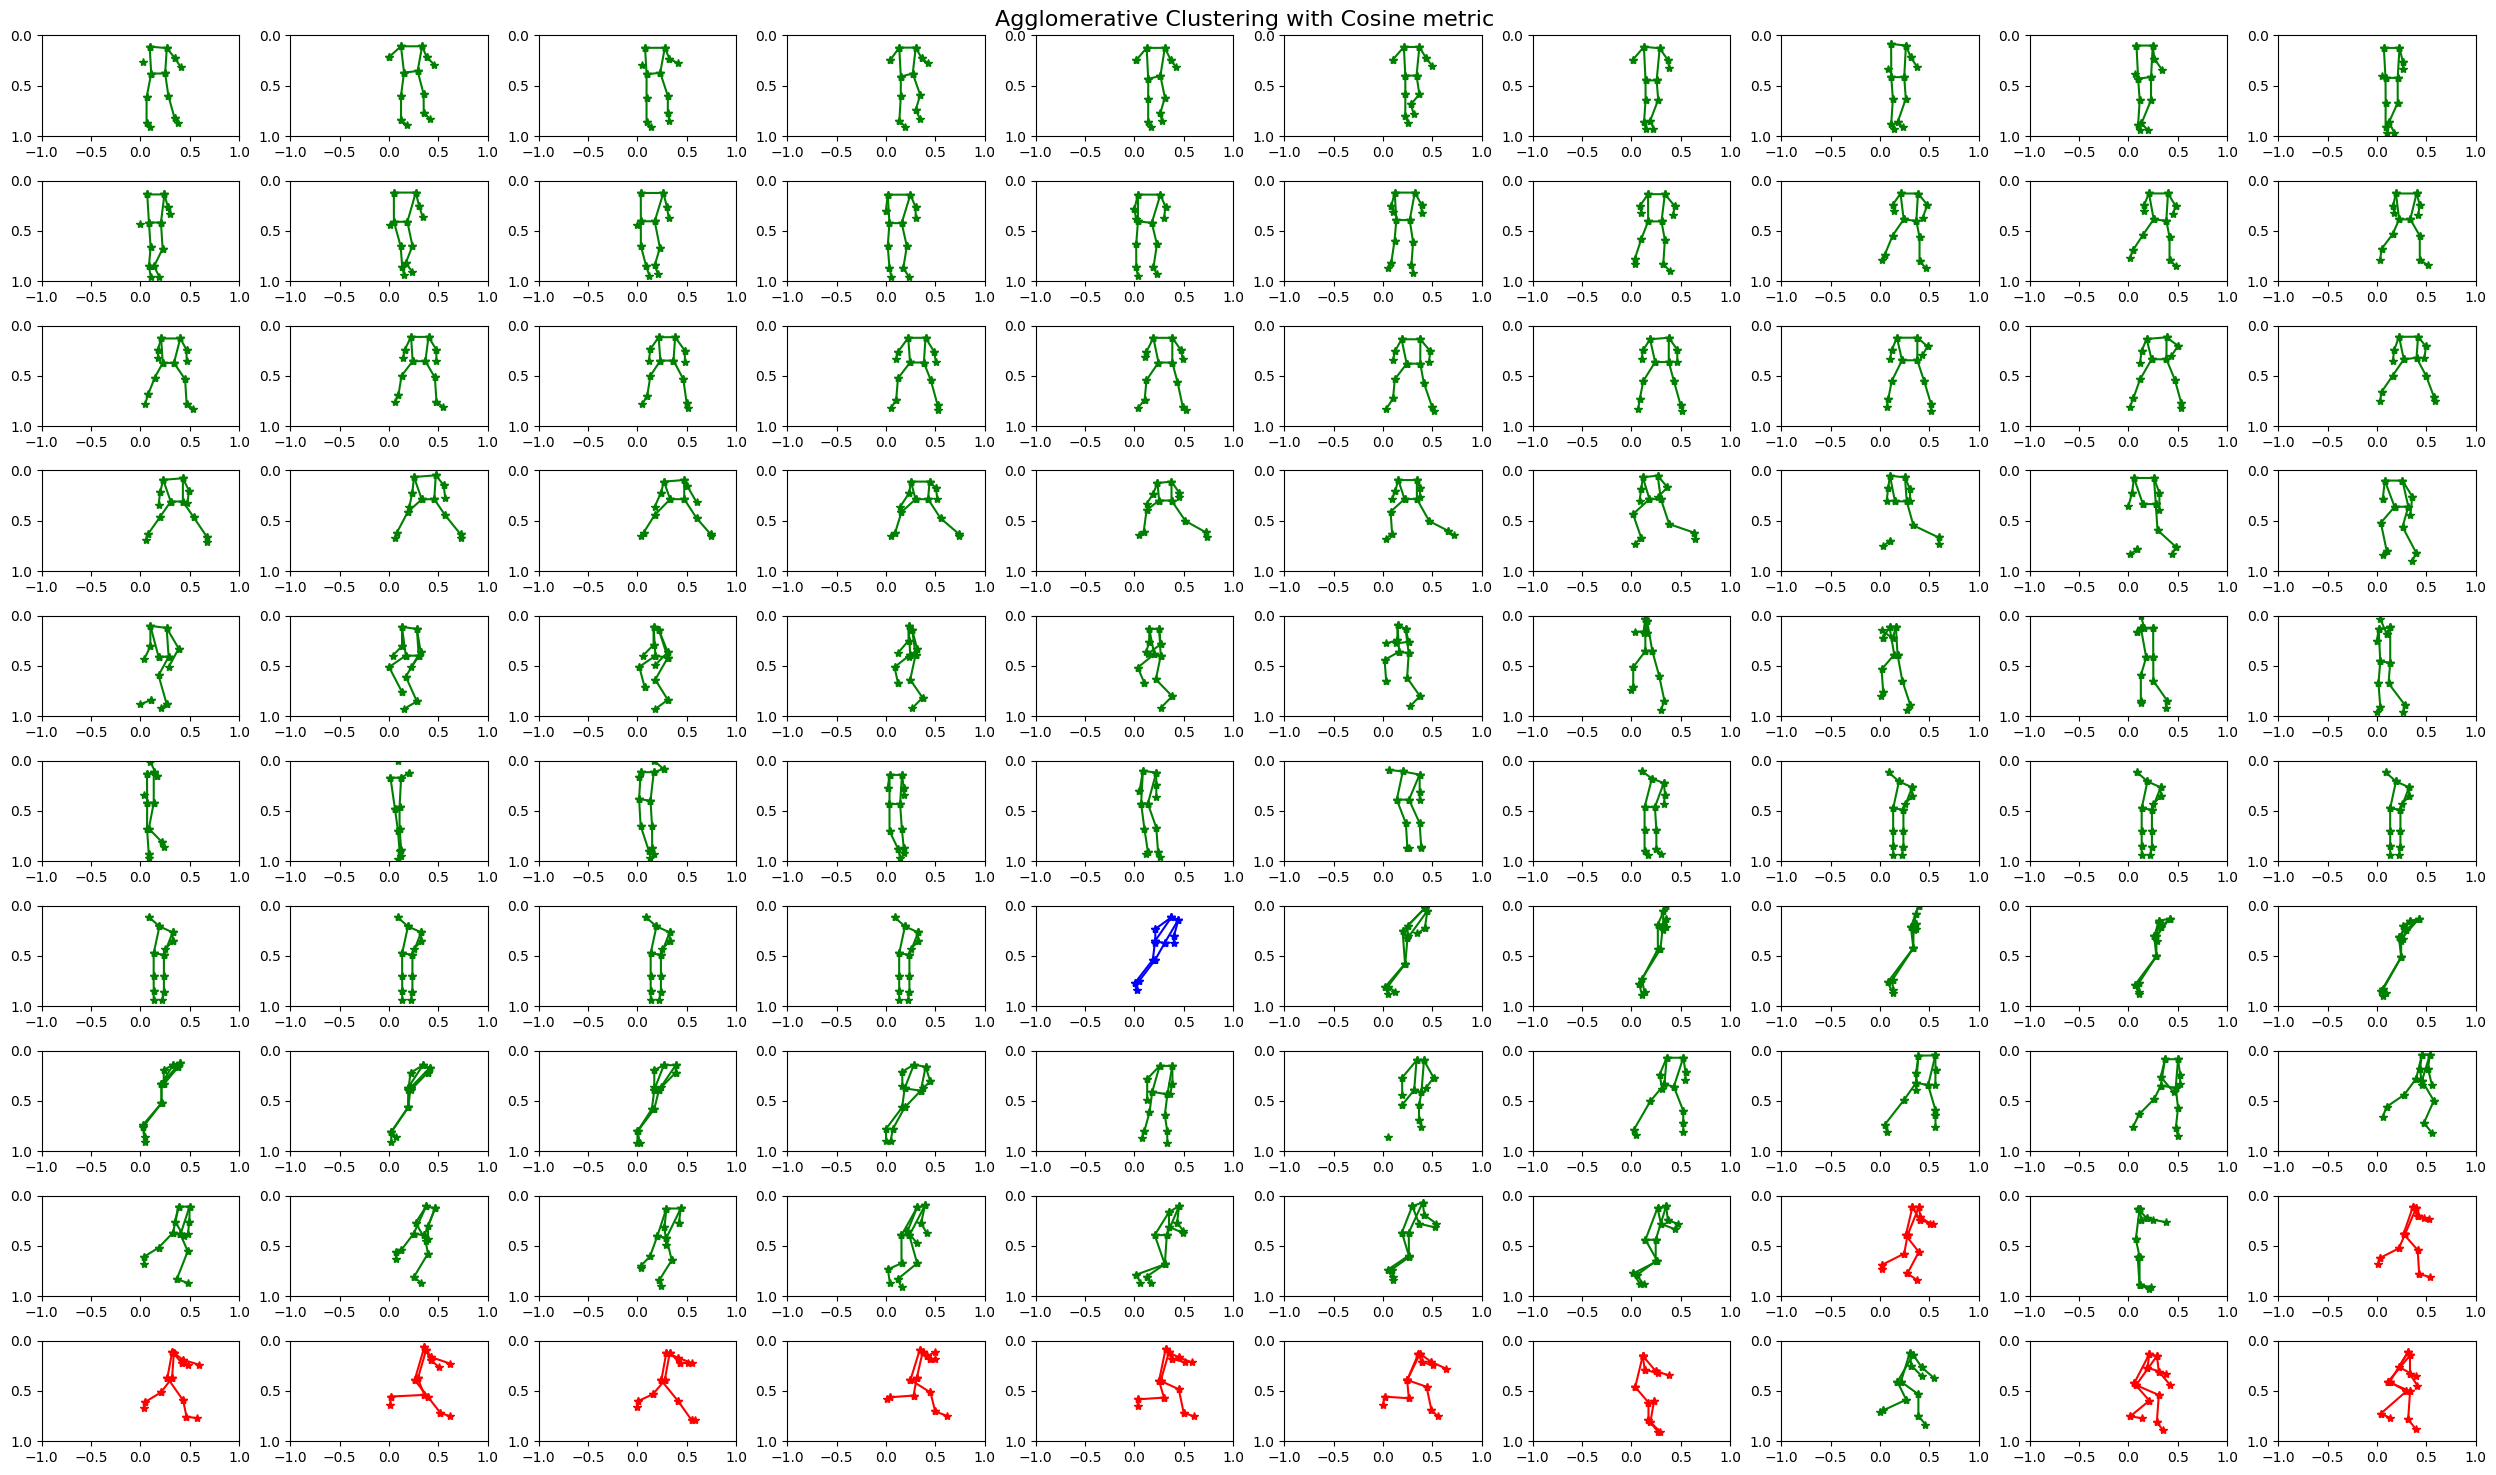

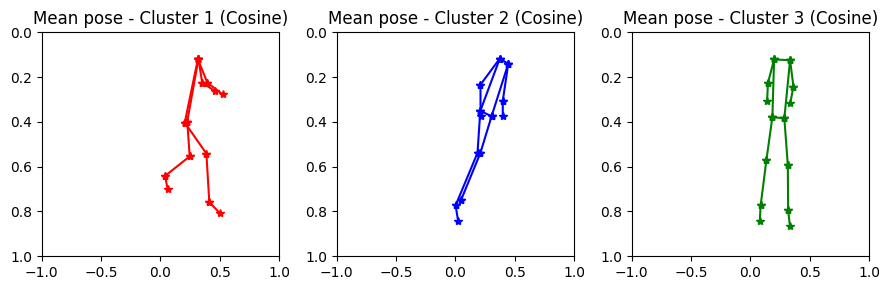

In [45]:
# Write your solution here

# Part 1: Calculate and plot mean poses for k=3 (using euclidean metric from Task 14)
# Assuming you've already run Task 14 with n_clusters=3

# Calculate mean pose for each cluster
num_clusters = 3
cluster_centers = []

for cluster_id in range(num_clusters):
    # Get all poses belonging to this cluster
    cluster_mask = cluster_labels == cluster_id
    cluster_poses = sequence[cluster_mask]
    
    # Calculate mean pose (average across all poses in the cluster)
    mean_pose = np.mean(cluster_poses, axis=0)
    cluster_centers.append(mean_pose)

# Convert to numpy array for easier handling
cluster_centers = np.array(cluster_centers)

# Plot the mean poses
colors = {0: 'red', 1: 'blue', 2: 'green'}
fig, axes = plt.subplots(1, num_clusters, figsize=(num_clusters * 3, 3))

for i in range(num_clusters):
    plt.subplot(1, num_clusters, i+1)
    plt.title(f'Mean pose - Cluster {i+1}')
    plot_single_pose(cluster_centers[i], c=colors[i], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)

plt.tight_layout()
plt.show()

# Part 2: Repeat with different distance metrics (l1 and cosine)

# L1 (Manhattan) metric
print("=" * 50)
print("Using L1 (Manhattan) metric:")
print("=" * 50)

agg_clustering_l1 = AgglomerativeClustering(n_clusters=3, metric='l1', linkage='average')
agg_clustering_l1.fit(sequence)
cluster_labels_l1 = agg_clustering_l1.labels_

# Visualize clusters with L1
colors = {0: 'red', 1: 'blue', 2: 'green'}
plt.figure(figsize=(25,15))
for i in range(len(sequence)):
    plt.subplot(10, 10, i + 1)
    plot_single_pose(sequence[i], c=colors[cluster_labels_l1[i]], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)
plt.suptitle('Agglomerative Clustering with L1 metric', fontsize=16)
plt.tight_layout()
plt.show()

# Calculate and plot mean poses for L1
cluster_centers_l1 = []
for cluster_id in range(num_clusters):
    cluster_mask = cluster_labels_l1 == cluster_id
    cluster_poses = sequence[cluster_mask]
    mean_pose = np.mean(cluster_poses, axis=0)
    cluster_centers_l1.append(mean_pose)

cluster_centers_l1 = np.array(cluster_centers_l1)

fig, axes = plt.subplots(1, num_clusters, figsize=(num_clusters * 3, 3))
for i in range(num_clusters):
    plt.subplot(1, num_clusters, i+1)
    plt.title(f'Mean pose - Cluster {i+1} (L1)')
    plot_single_pose(cluster_centers_l1[i], c=colors[i], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)
plt.tight_layout()
plt.show()

# Cosine metric
print("=" * 50)
print("Using Cosine metric:")
print("=" * 50)

agg_clustering_cosine = AgglomerativeClustering(n_clusters=3, metric='cosine', linkage='average')
agg_clustering_cosine.fit(sequence)
cluster_labels_cosine = agg_clustering_cosine.labels_

# Visualize clusters with Cosine
plt.figure(figsize=(25,15))
for i in range(len(sequence)):
    plt.subplot(10, 10, i + 1)
    plot_single_pose(sequence[i], c=colors[cluster_labels_cosine[i]], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)
plt.suptitle('Agglomerative Clustering with Cosine metric', fontsize=16)
plt.tight_layout()
plt.show()

# Calculate and plot mean poses for Cosine
cluster_centers_cosine = []
for cluster_id in range(num_clusters):
    cluster_mask = cluster_labels_cosine == cluster_id
    cluster_poses = sequence[cluster_mask]
    mean_pose = np.mean(cluster_poses, axis=0)
    cluster_centers_cosine.append(mean_pose)

cluster_centers_cosine = np.array(cluster_centers_cosine)

fig, axes = plt.subplots(1, num_clusters, figsize=(num_clusters * 3, 3))
for i in range(num_clusters):
    plt.subplot(1, num_clusters, i+1)
    plt.title(f'Mean pose - Cluster {i+1} (Cosine)')
    plot_single_pose(cluster_centers_cosine[i], c=colors[i], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)
plt.tight_layout()
plt.show()


---
**Task 16 (easy): Agglomerative clustreing algorithm mean pose💡📽️**
1. What differences do you observe?
2. Explain why these differences occur? 
3. Does a different distance metric result in more meaningful clusters, why/why not?


---

## Task 16: Agglomerative Clustering Algorithm Mean Pose - Reflections

### 1. What differences do you observe?

After comparing the clustering results using different distance metrics (Euclidean, L1/Manhattan, and Cosine), I observe several key differences:

**Cluster assignments:**
- **Different pose groupings**: The same poses are often assigned to different clusters depending on the metric used. For example, a pose that belongs to cluster 0 with Euclidean distance might belong to cluster 1 with L1 or Cosine distance.

- **Cluster sizes**: The distribution of poses across the three clusters varies between metrics. Some clusters may be larger or smaller depending on the distance metric used.

**Mean pose characteristics:**
- **Shape differences**: The mean poses (cluster centers) computed for each metric show different characteristics. The mean poses from Euclidean clustering may have different arm/leg positions compared to those from L1 or Cosine clustering.

- **Smoothness**: The mean poses from different metrics may appear more or less "smooth" or "averaged" depending on how the metric groups similar poses.

**Visual clustering patterns:**
- **Temporal continuity**: With Euclidean distance, clusters may show more temporal continuity (adjacent frames in the sequence belonging to the same cluster), while L1 or Cosine might create more fragmented groupings.

- **Boundary placement**: The boundaries between clusters (where one cluster ends and another begins in the sequence) differ across metrics, suggesting different interpretations of pose similarity.

### 2. Explain why these differences occur?

The differences occur because each distance metric measures similarity between poses in fundamentally different ways:

**Euclidean distance (L2):**
- Measures the straight-line distance between two points in the 50-dimensional pose space
- Treats all dimensions equally and is sensitive to outliers
- Emphasizes large differences in any single dimension
- **Why it groups poses**: Poses with similar overall joint positions (in terms of Euclidean distance) are grouped together
- **Effect**: Tends to create clusters based on overall pose configuration

**L1 (Manhattan) distance:**
- Measures the sum of absolute differences across all dimensions
- More robust to outliers than Euclidean distance
- Treats each dimension independently and linearly
- **Why it groups poses**: Poses with similar cumulative differences across all joints are grouped together, but it's less sensitive to a single joint being very different
- **Effect**: May group poses that are similar in most joints but differ significantly in one or two joints, which Euclidean might separate

**Cosine distance:**
- Measures the angle between two vectors, focusing on direction rather than magnitude
- Normalizes for the scale/length of the pose vector
- Emphasizes the relative proportions and shape of the pose rather than absolute positions
- **Why it groups poses**: Poses with similar shapes/orientations (regardless of scale) are grouped together
- **Effect**: May group poses that have similar body configurations but different scales or positions in space

**Linkage method interaction:**
- The choice of linkage method (ward, average, complete) also affects results
- Ward linkage (used with Euclidean) minimizes variance within clusters
- Average linkage (used with L1 and Cosine) considers average distances between cluster members
- This further contributes to differences in cluster formation

**Mathematical foundation:**
- Each metric defines a different geometry in the pose space
- Euclidean assumes a spherical geometry
- L1 assumes a diamond/octahedral geometry
- Cosine assumes a geometry on the unit sphere
- These different geometries lead to different notions of "closeness" and thus different clusterings

### 3. Does a different distance metric result in more meaningful clusters, why/why not?

The answer depends on what "meaningful" means in the context of pose analysis:

**Euclidean distance may be more meaningful when:**
- **Absolute pose positions matter**: If the exact spatial positions of joints are important (e.g., distinguishing between standing and sitting based on absolute height)
- **Overall pose configuration is key**: When the complete pose configuration is what matters, Euclidean captures this well
- **Standard pose analysis**: Often the default choice for pose data as it naturally captures spatial relationships

**L1 (Manhattan) distance may be more meaningful when:**
- **Robustness to outliers is needed**: If some joints are noisy or unreliable, L1 is less affected by extreme values
- **Piecewise similarity matters**: When poses are similar in most joints but differ in a few, L1 may better capture this
- **Sparse differences**: When the important differences are spread across many dimensions rather than concentrated

**Cosine distance may be more meaningful when:**
- **Pose shape/orientation is more important than scale**: If you want to group poses with similar body configurations regardless of how "large" or "small" the pose appears
- **Relative proportions matter**: When the relative positions of joints (e.g., arm-to-body ratio) are more important than absolute positions
- **Normalized pose analysis**: When poses have been normalized or when scale variations are not meaningful

**For human pose sequences specifically:**
- **Euclidean is likely most meaningful** for most applications because:
  - Human poses are naturally represented in spatial coordinates where Euclidean distance has physical meaning
  - The absolute positions of joints relative to the body center are important for distinguishing different poses
  - It aligns with how humans perceive pose similarity (overall spatial configuration)
  
- **However, the "best" metric depends on the application:**
  - If analyzing movement patterns where shape matters more than position → Cosine might be better
  - If dealing with noisy data where robustness is critical → L1 might be better
  - If standard pose analysis where spatial relationships are key → Euclidean is typically best

**Conclusion:**
While different metrics reveal different aspects of the data, **Euclidean distance generally produces more meaningful clusters for pose data** because it directly corresponds to spatial relationships between joints, which is the natural way to think about human poses. However, the choice should be guided by the specific research question or application. The differences observed highlight that clustering is not just a technical procedure but involves making assumptions about what "similarity" means for the data at hand.

## Comparison

---
**Task 17 (medium): Compare and reflect on the methods👩‍💻💡📽️**
1. Compare the clustered poses obtained with the different clustering methods (K-means, Mean-shift and Agglomerative clustering). What are the similarities and differences between the pose clusters across methods?
2. Why can clusters look similar across methods? 
3. What are the main reasons behind differences in the clusters?
4. The algorithms use different methods for determining the number of clusters. How do these differences impact the results for the pose data?


---

## Task 17: Compare and Reflect on the Methods

### 1. Compare the clustered poses obtained with the different clustering methods (K-means, Mean-shift and Agglomerative clustering). What are the similarities and differences between the pose clusters across methods?

**Similarities:**

- **Common pose groupings**: Despite using different algorithms, all three methods tend to identify similar fundamental pose categories. For example, standing poses, walking/dynamic poses, and reaching/bending poses are often separated across all methods, suggesting these represent natural groupings in the data.

- **Cluster center characteristics**: The mean poses (cluster centers) from different methods often show similar body configurations, indicating that the algorithms are converging on similar prototypical poses that represent the data well.

- **Temporal patterns**: All methods show some degree of temporal continuity, where adjacent frames in the sequence often belong to the same cluster, reflecting the smooth nature of human movement.

- **Core pose distinctions**: The fundamental distinctions between major pose types (e.g., upright vs. leaning, arms raised vs. lowered) are captured by all methods, suggesting these are robust features of the data.

**Differences:**

- **Number of clusters**: 
  - **K-means**: Requires pre-specifying k (e.g., 7 clusters, or optimal k from elbow method)
  - **Mean-shift**: Automatically determines the number of clusters based on bandwidth (e.g., 10 clusters with bandwidth 0.429, fewer with higher bandwidth)
  - **Agglomerative**: Can use either n_clusters or distance_threshold (e.g., 3 clusters with distance threshold ~2.0)

- **Cluster granularity**:
  - **K-means**: Produces clusters of relatively uniform size (when k is fixed), creating balanced groupings
  - **Mean-shift**: Can produce clusters of varying sizes, with some clusters containing many poses and others containing few, depending on local density
  - **Agglomerative**: Creates hierarchical structure, allowing exploration at different granularities

- **Cluster boundaries**:
  - **K-means**: Creates hard boundaries with clear cluster assignments; poses are assigned to the nearest centroid
  - **Mean-shift**: Boundaries are determined by density peaks; poses in low-density regions may form separate small clusters
  - **Agglomerative**: Boundaries depend on the chosen distance threshold or number of clusters; can reveal nested cluster structure

- **Sensitivity to initialization**:
  - **K-means**: Results can vary with different random seeds (though less so with k-means++ initialization)
  - **Mean-shift**: Deterministic given the same bandwidth and data
  - **Agglomerative**: Deterministic given the same parameters

- **Cluster shape assumptions**:
  - **K-means**: Assumes spherical clusters (works best with roughly circular clusters in feature space)
  - **Mean-shift**: Can capture clusters of arbitrary shape based on density
  - **Agglomerative**: Can capture clusters of various shapes depending on linkage method

### 2. Why can clusters look similar across methods?

Clusters can look similar across methods for several fundamental reasons:

**Underlying data structure:**
- The pose data has **natural groupings** that are inherent to the movement patterns. These groupings are robust and can be discovered by different algorithms, even if they use different approaches. For example, standing poses naturally form a distinct group from walking poses because they occupy different regions of the pose space.

**Common optimization objectives:**
- Despite different algorithms, all methods aim to **group similar poses together** and **separate dissimilar poses**. This shared objective leads to similar results when the data has clear structure.

**Geometric properties:**
- The pose data likely has **well-separated clusters** in the feature space. When clusters are clearly separated, different algorithms will tend to identify the same major groupings, even if they differ in details.

**Distance-based similarity:**
- All methods fundamentally rely on **distance metrics** (Euclidean, etc.) to measure pose similarity. Since they're using similar notions of distance, they naturally identify similar groupings.

**Temporal continuity:**
- Human movement is **smooth and continuous**, so poses that are temporally adjacent are also similar in feature space. This temporal structure is captured by all methods, leading to similar cluster assignments for consecutive frames.

**Robust features:**
- The key distinguishing features of poses (e.g., arm positions, body orientation, leg configuration) are **robust** and can be identified by different algorithms, leading to similar cluster characterizations.

### 3. What are the main reasons behind differences in the clusters?

The differences arise from fundamental algorithmic and methodological differences:

**Algorithm design philosophy:**

- **K-means**: 
  - **Partitioning approach**: Divides data into k partitions by minimizing within-cluster variance
  - **Assumes fixed k**: Must specify number of clusters in advance
  - **Centroid-based**: Each cluster represented by a single centroid
  - **Result**: Creates balanced, spherical clusters

- **Mean-shift**:
  - **Density-based approach**: Finds modes (peaks) in the data density
  - **Automatic k**: Number of clusters determined by number of density peaks
  - **Bandwidth-dependent**: Bandwidth parameter controls cluster granularity
  - **Result**: Can create clusters of varying sizes and shapes based on local density

- **Agglomerative**:
  - **Hierarchical approach**: Builds clusters bottom-up by merging similar points/clusters
  - **Flexible k**: Can specify either number of clusters or distance threshold
  - **Linkage-dependent**: Different linkage methods (ward, average, complete) create different clusterings
  - **Result**: Reveals hierarchical structure and allows multiple valid clusterings

**Parameter choices:**

- **K-means**: Choice of k significantly affects results; elbow method helps but still requires judgment
- **Mean-shift**: Bandwidth parameter is critical; small bandwidth → many clusters, large bandwidth → few clusters
- **Agglomerative**: Choice between n_clusters and distance_threshold, plus linkage method, all affect results

**Cluster shape assumptions:**

- **K-means**: Assumes clusters are roughly spherical; struggles with elongated or irregular shapes
- **Mean-shift**: Can capture arbitrary cluster shapes based on density contours
- **Agglomerative**: Shape depends on linkage; ward creates compact clusters, single/complete can create elongated clusters

**Optimization criteria:**

- **K-means**: Minimizes within-cluster sum of squares (WCSS)
- **Mean-shift**: Maximizes density at cluster centers
- **Agglomerative**: Minimizes linkage distance between merged clusters

**Handling of outliers and noise:**

- **K-means**: Outliers can pull centroids away from main cluster
- **Mean-shift**: Outliers may form separate small clusters or be ignored if bandwidth is large
- **Agglomerative**: Outliers merge late in the hierarchy, making them easy to identify

**Computational approach:**

- **K-means**: Iterative optimization that may converge to local minima
- **Mean-shift**: Gradient ascent on density function
- **Agglomerative**: Greedy bottom-up merging

### 4. The algorithms use different methods for determining the number of clusters. How do these differences impact the results for the pose data?

**K-means - Pre-specified k:**

- **Impact**: Requires external method (like elbow method) to determine optimal k
- **Advantage**: Gives explicit control over granularity; can choose k based on domain knowledge or analysis goals
- **Disadvantage**: May not match natural number of clusters in data; forces data into k groups even if natural structure suggests different number
- **For pose data**: 
  - Elbow method might suggest k=5-7, but this is a heuristic
  - May create artificial splits or merges if k doesn't match natural groupings
  - Good when you have prior knowledge about expected number of movement phases

**Mean-shift - Automatic via bandwidth:**

- **Impact**: Number of clusters emerges from data density structure
- **Advantage**: Discovers natural number of clusters based on data; no need to pre-specify
- **Disadvantage**: Sensitive to bandwidth choice; small changes in bandwidth can dramatically change number of clusters
- **For pose data**:
  - With bandwidth 0.429 → many clusters (e.g., 10), capturing fine-grained distinctions
  - With bandwidth 0.829 → fewer clusters (e.g., 3-5), capturing broader patterns
  - May create too many clusters (over-segmentation) or too few (under-segmentation) depending on bandwidth
  - Good for exploratory analysis where you want to discover natural groupings

**Agglomerative - Flexible (n_clusters or distance_threshold):**

- **Impact**: Can use either approach, and dendrogram provides guidance
- **Advantage**: 
  - Dendrogram shows all possible clusterings at different levels
  - Can choose based on natural breaks in dendrogram (long vertical lines)
  - Distance threshold approach respects natural cluster boundaries
- **Disadvantage**: Still requires choice of threshold or n_clusters; interpretation of dendrogram can be subjective
- **For pose data**:
  - Dendrogram reveals hierarchical structure (e.g., 2 main branches, 3 sub-groups)
  - Distance threshold ~2.0 might naturally give 3 clusters based on dendrogram structure
  - Allows exploration at multiple levels (coarse vs. fine)
  - Good when you want to understand hierarchical relationships in movement

**Comparative impact on pose data:**

- **Granularity mismatch**: 
  - If pose sequence has 5 natural movement phases but k-means uses k=7, it may artificially split some phases
  - Mean-shift with wrong bandwidth might create 10 clusters when 5 would be more meaningful
  - Agglomerative allows choosing the level that matches natural structure

- **Interpretability**:
  - K-means with optimal k (from elbow) → clear, interpretable clusters matching movement phases
  - Mean-shift → clusters may be too fine or too coarse depending on bandwidth
  - Agglomerative → can choose level that best matches semantic movement phases

- **Robustness**:
  - K-means: Results depend on k choice, which may vary with different analysis
  - Mean-shift: Results depend on bandwidth, which requires tuning
  - Agglomerative: Dendrogram provides stable visualization of all possibilities

- **Practical implications**:
  - For pose analysis, the "best" method depends on the goal:
    - **Detailed phase analysis** → Mean-shift with low bandwidth or Agglomerative with low threshold
    - **General movement categories** → K-means with moderate k or Mean-shift with high bandwidth
    - **Exploratory analysis** → Agglomerative with dendrogram to explore multiple levels
    - **Reproducible analysis** → K-means with fixed k or Agglomerative with fixed threshold

**Conclusion:**

The different approaches to determining cluster number reflect different philosophies: K-means requires explicit specification (with guidance from elbow method), Mean-shift discovers clusters automatically (but requires bandwidth tuning), and Agglomerative provides flexibility to explore multiple levels. For pose data, this means that the "correct" number of clusters depends not just on the data, but on the analysis goals and the method chosen. The hierarchical nature of movement (phases within actions, actions within sequences) means that different methods may reveal different but equally valid aspects of the pose structure.